# Real-data evaluation

Goal: evaluate PLEM's metrics on real geometry (not synthetic shapes) and record observations, using the curated samples built by `spacenet_data_prep.ipynb` (road/building) and `potsdam_data_prep.ipynb` (point features).

**Scope-defining assumption:** PLEM has no trained extractor and none is in scope here (no GPU, per project constraints). So "pred" in this notebook is the real ground truth run through the *same* perturbation families already used in `tests/test_sensitivity.py` (offset / erosion / dropout / thickening for roads & buildings; jitter / dropout / clutter for points), at fixed severity levels. This isolates the actual question -- does real, irregular geometry (winding roads, non-rectangular parcels, clustered trees/cars) change how a metric behaves, compared to the idealized synthetic shapes in the existing sanity/sensitivity tests -- from "do we have a working extractor," which isn't what's being tested.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import (
    shift as nd_shift, binary_erosion, binary_dilation, center_of_mass, label as cc_label,
)

from metrics import evaluate_all, point_f1_multiclass

# Resolve to an absolute path so this reads/writes the repo's data/ dir
# regardless of the kernel's working directory (nbconvert runs notebooks with
# CWD set to the notebook's own folder, not the repo root).
DATA_DIR = Path("..").resolve() / "data"
CITIES = ["Vegas", "Khartoum"]

# Fixed categorical palette (validated for CVD-safe adjacent contrast --
# see the dataviz skill's reference palette). Each metric keeps the same
# color in every chart in this notebook. The area-weighted/lenient companion
# figures (cbhm_soft, dtaf1_weighted) reuse their base metric's color and are
# distinguished by linestyle (dashed) instead of a new hue -- they're variants
# of the same underlying score, not a separate metric family.
METRIC_COLORS = {
    "cbhm": "#2a78d6",         # blue
    "cbhm_soft": "#2a78d6",    # blue (dashed)
    "dtaf1": "#4a3aa7",        # violet
    "dtaf1_weighted": "#4a3aa7",  # violet (dashed)
    "cldice_mean": "#1baf7a",  # aqua
    "bf_mean": "#eb6834",      # orange
    "point_f1": "#2a78d6",     # blue
    "precision": "#1baf7a",    # aqua
    "recall": "#eb6834",       # orange
}

In [2]:
# Load cached SpaceNet road/building tiles (run spacenet_data_prep.ipynb first)
spacenet_tiles = []
for city in CITIES:
    for p in sorted((DATA_DIR / "spacenet" / city).glob("*.npz")):
        d = np.load(p)
        spacenet_tiles.append({"city": city, "tile": p.stem, "image": d["image"], "label": d["label"]})
print(f"Loaded {len(spacenet_tiles)} SpaceNet tiles across {CITIES}")

# Load cached Potsdam point crops (run potsdam_data_prep.ipynb first) -- optional,
# this section is skipped gracefully if not yet built (e.g. Kaggle token pending).
potsdam_dir = DATA_DIR / "potsdam"
potsdam_crops = []
if potsdam_dir.exists():
    for p in sorted(potsdam_dir.glob("*.npz")):
        d = np.load(p)
        potsdam_crops.append({"tile": p.stem, "image": d["image"], "label": d["label"]})
print(f"Loaded {len(potsdam_crops)} Potsdam point crops"
      + ("" if potsdam_crops else " -- none found yet, point-feature section below will be skipped"))

Loaded 24 SpaceNet tiles across ['Vegas', 'Khartoum']
Loaded 15 Potsdam point crops


## Perturbation families

Same families as `tests/test_sensitivity.py`'s synthetic sweeps, applied here to real GT label maps instead of idealized shapes.

In [3]:
def perturb_offset(label, cls, offset_px, axis=1):
    """Shift one class's pixels by offset_px along `axis`, leaving other classes untouched."""
    out = label.copy()
    cls_mask = (label == cls)
    shifted = nd_shift(cls_mask.astype(np.uint8), shift=[offset_px if a == axis else 0 for a in range(2)],
                        order=0, mode="constant", cval=0)
    out[cls_mask] = 0
    out[shifted > 0] = cls
    return out


def perturb_erode(label, cls, iterations):
    out = label.copy()
    cls_mask = (label == cls)
    eroded = binary_erosion(cls_mask, iterations=iterations) if iterations > 0 else cls_mask
    out[cls_mask] = 0
    out[eroded] = cls
    return out


def perturb_dilate(label, cls, iterations):
    out = label.copy()
    cls_mask = (label == cls)
    dilated = binary_dilation(cls_mask, iterations=iterations) if iterations > 0 else cls_mask
    # don't let dilation overwrite other real classes
    dilated = dilated & (label != (3 - cls) if cls in (1, 2) else True)
    out[dilated] = cls
    return out


def perturb_dropout(label, cls, fraction, rng):
    out = label.copy()
    idx = np.argwhere(label == cls)
    if len(idx) == 0 or fraction <= 0:
        return out
    n_remove = int(fraction * len(idx))
    if n_remove == 0:
        return out
    drop = idx[rng.choice(len(idx), n_remove, replace=False)]
    out[drop[:, 0], drop[:, 1]] = 0
    return out

## Road/building perturbation sweep across all SpaceNet tiles

Applied to every cached SpaceNet tile (24 tiles across Vegas + Khartoum). Each perturbation isolates one failure mode a real road/building extractor can produce:

- **`road_offset`** -- shifts the entire road class sideways by `severity` pixels (0, 4, 8, 12, 16), simulating a systematic centerline registration error (e.g. from georeferencing drift or a slightly-off extraction). Building pixels are untouched.
- **`road_dropout`** -- randomly deletes `severity` fraction of road pixels (0%, 25%, 50%, 75%), simulating fragmentation/breakage in the extracted network (occluded segments, low-confidence gaps). This is the failure mode DTAF1 is known to under-penalize (see CLAUDE.md) -- scattered surviving pixels still fall inside the tolerance radius of GT.
- **`road_thicken`** -- dilates the road class by `severity` pixels (0, 2, 4, 6), simulating an extractor that over-predicts road width without moving the centerline. IoU penalizes this harshly; clDice/DTAF1 should not.
- **`building_erode`** -- erodes the building class by `severity` pixels (0, 1, 2, 3), simulating an extractor that shrinks building footprints inward from the true boundary (a common effect of confidence thresholding).

In [4]:
rng = np.random.default_rng(0)

PERTURBATIONS = {
    "road_offset":     lambda gt, sev: perturb_offset(gt, cls=1, offset_px=sev),
    "road_dropout":    lambda gt, sev: perturb_dropout(gt, cls=1, fraction=sev, rng=rng),
    "road_thicken":    lambda gt, sev: perturb_dilate(gt, cls=1, iterations=sev),
    "building_erode":  lambda gt, sev: perturb_erode(gt, cls=2, iterations=sev),
}
SEVERITIES = {
    "road_offset":    [0, 4, 8, 12, 16],
    "road_dropout":   [0.0, 0.25, 0.5, 0.75],
    "road_thicken":   [0, 2, 4, 6],
    "building_erode": [0, 1, 2, 3],
}

rows = []
for t in spacenet_tiles:
    gt = t["label"]
    for pert_name, pert_fn in PERTURBATIONS.items():
        for sev in SEVERITIES[pert_name]:
            pred = pert_fn(gt, sev)
            result = evaluate_all(pred, gt, linear_classes=[1], polygon_classes=[2])
            rows.append({
                "city": t["city"], "tile": t["tile"],
                "perturbation": pert_name, "severity": sev,
                "cbhm": result["cbhm"], "cbhm_soft": result["cbhm_soft"],
                "dtaf1": result["dtaf1"], "dtaf1_weighted": result["dtaf1_weighted"],
                "cldice_mean": result["cldice_mean"], "bf_mean": result["bf_mean"],
            })

real_results = pd.DataFrame(rows)
real_results.to_csv(DATA_DIR / "real_data_evaluation_results.csv", index=False)
real_results.head()

,city,tile,perturbation,severity,cbhm,cbhm_soft,dtaf1,dtaf1_weighted,cldice_mean,bf_mean
0,Vegas,Vegas_img1015,road_offset,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
1,Vegas,Vegas_img1015,road_offset,4.0,0.996412,0.996431,1.000000,1.000000,0.992849,1.0
2,Vegas,Vegas_img1015,road_offset,8.0,0.909338,0.917026,0.999032,0.999034,0.833749,1.0
3,Vegas,Vegas_img1015,road_offset,12.0,0.806879,0.838432,0.983400,0.983430,0.676276,1.0
4,Vegas,Vegas_img1015,road_offset,16.0,0.798328,0.832479,0.955046,0.955128,0.664347,1.0


In [5]:
# Summary stats per perturbation/severity across the real sample
summary = (
    real_results
    .groupby(["perturbation", "severity"])[["cbhm", "cbhm_soft", "dtaf1", "dtaf1_weighted", "cldice_mean", "bf_mean"]]
    .agg(["mean", "std"])
)
summary

cbhm           cbhm_soft               dtaf1  \
                             mean       std      mean       std      mean   
perturbation   severity                                                     
building_erode 0.00      1.000000  0.000000  1.000000  0.000000  1.000000   
               1.00      0.999860  0.000240  0.999905  0.000137  0.999907   
               2.00      0.997797  0.001849  0.998271  0.001156  0.998266   
               3.00      0.979792  0.011278  0.983901  0.008109  0.978785   
road_dropout   0.00      1.000000  0.000000  1.000000  0.000000  1.000000   
               0.25      0.922217  0.006363  0.915155  0.030759  1.000000   
               0.50      0.798560  0.006050  0.803255  0.068768  1.000000   
               0.75      0.567578  0.026932  0.645653  0.125332  1.000000   
road_offset    0.00      1.000000  0.000000  1.000000  0.000000  1.000000   
               4.00      0.997068  0.008408  0.996303  0.011552  0.999971   
               8.00      0.925212  0.135745  0.937418  0.103662  0.999804   
               12.00     0.712500  0.203819  0.749567  0.183512  0.978493   
               16.00     0.669490  0.201228  0.711646  0.197220  0.932289   
road_thicken   0.00      1.000000  0.000000  1.000000  0.000000  1.000000   
               2.00      0.999371  0.001435  0.999182  0.002061  1.000000   
               4.00      0.996587  0.008022  0.996491  0.007379  1.000000   
               6.00      0.994251  0.011154  0.993444  0.013491  1.000000   

                                  dtaf1_weighted           cldice_mean  \
                              std           mean       std        mean   
perturbation   severity                                                  
building_erode 0.00      0.000000       1.000000  0.000000    1.000000   
               1.00      0.000135       0.999939  0.000076    1.000000   
               2.00      0.001481       0.998637  0.000928    1.000000   
               3.00      0.011080       0.982696  0.008585    1.000000   
road_dropout   0.00      0.000000       1.000000  0.000000    1.000000   
               0.25      0.000000       1.000000  0.000000    0.855722   
               0.50      0.000000       1.000000  0.000000    0.664710   
               0.75      0.000000       1.000000  0.000000    0.396679   
road_offset    0.00      0.000000       1.000000  0.000000    1.000000   
               4.00      0.000065       0.999968  0.000082    0.994321   
               8.00      0.000379       0.999806  0.000426    0.883008   
               12.00     0.014196       0.974956  0.021057    0.584128   
               16.00     0.042138       0.920674  0.062383    0.531804   
road_thicken   0.00      0.000000       1.000000  0.000000    1.000000   
               2.00      0.000000       1.000000  0.000000    0.998747   
               4.00      0.000000       1.000000  0.000000    0.993316   
               6.00      0.000000       1.000000  0.000000    0.988797   

                                    bf_mean            
                              std      mean       std  
perturbation   severity                                
building_erode 0.00      0.000000  1.000000  0.000000  
               1.00      0.000000  0.999721  0.000479  
               2.00      0.000000  0.995610  0.003664  
               3.00      0.000000  0.960609  0.021231  
road_dropout   0.00      0.000000  1.000000  0.000000  
               0.25      0.010693  1.000000  0.000000  
               0.50      0.008302  1.000000  0.000000  
               0.75      0.024595  1.000000  0.000000  
road_offset    0.00      0.000000  1.000000  0.000000  
               4.00      0.016149  0.999961  0.000088  
               8.00      0.182457  0.999752  0.000545  
               12.00     0.205365  0.999263  0.001587  
               16.00     0.198160  0.998470  0.003192  
road_thicken   0.00      0.000000  1.000000  0.000000  
               2.00      0.002851  1.000000  0.000000  

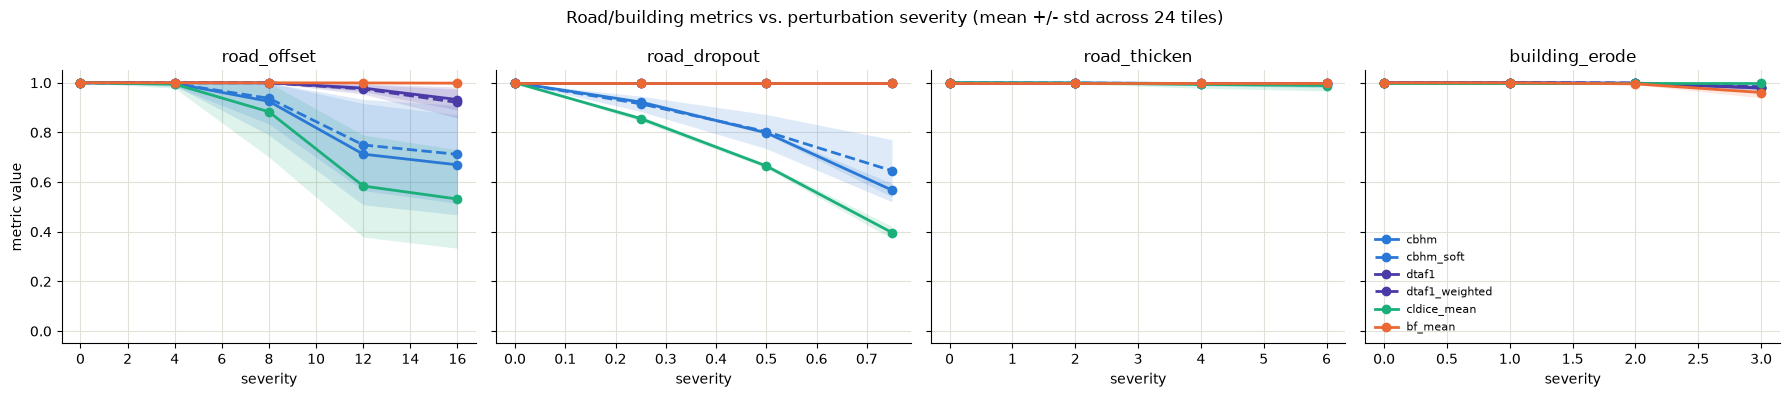

In [6]:
# Colorized small multiples: metric value vs. severity, one subplot per
# perturbation family. Shaded band = +/- 1 std across the 24 real tiles.
# Solid lines = harsh/unweighted originals (cbhm, dtaf1); dashed lines = the
# lenient, area-weighted companions (cbhm_soft, dtaf1_weighted).
metric_cols = ["cbhm", "cbhm_soft", "dtaf1", "dtaf1_weighted", "cldice_mean", "bf_mean"]
DASHED_METRICS = {"cbhm_soft", "dtaf1_weighted"}

fig, axes = plt.subplots(1, len(PERTURBATIONS), figsize=(4.5 * len(PERTURBATIONS), 4),
                          sharey=True)
for ax, pert_name in zip(axes, PERTURBATIONS):
    sub = real_results[real_results["perturbation"] == pert_name]
    stats = sub.groupby("severity")[metric_cols].agg(["mean", "std"])
    for metric in metric_cols:
        mean = stats[(metric, "mean")]
        std = stats[(metric, "std")]
        color = METRIC_COLORS[metric]
        linestyle = "--" if metric in DASHED_METRICS else "-"
        ax.plot(mean.index, mean.values, marker="o", color=color, label=metric,
                 linewidth=2, linestyle=linestyle)
        ax.fill_between(mean.index, (mean - std).clip(lower=0), (mean + std).clip(upper=1),
                         color=color, alpha=0.15, linewidth=0)
    ax.set_title(pert_name)
    ax.set_xlabel("severity")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("metric value")
axes[-1].legend(loc="lower left", frameon=False, fontsize=8)
fig.suptitle("Road/building metrics vs. perturbation severity (mean +/- std across 24 tiles)")
fig.tight_layout()
plt.show()

## Qualitative before/after example

One real tile's GT vs. a moderately perturbed prediction, with scores -- on real, irregular geometry (winding roads, non-rectangular parcels) rather than the straight synthetic stripes/rectangles in the existing sanity tests.

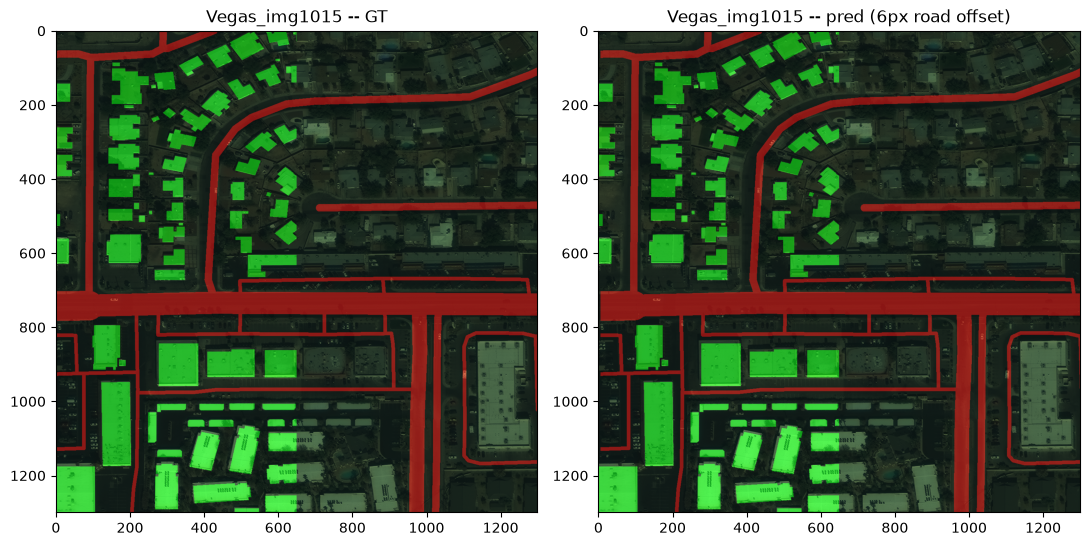

cbhm=0.911  cbhm_soft=0.919  dtaf1=1.000  dtaf1_weighted=1.000  cldice_mean=0.837  bf_mean=1.000


In [7]:
example_tile = spacenet_tiles[0]
gt = example_tile["label"]
pred = perturb_offset(gt, cls=1, offset_px=6)  # moderate road offset, building untouched
result = evaluate_all(pred, gt, linear_classes=[1], polygon_classes=[2])

def overlay(label):
    o = np.zeros((*label.shape, 3), dtype=np.uint8)
    o[label == 1] = [255, 0, 0]
    o[label == 2] = [0, 255, 0]
    return o

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].imshow(example_tile["image"]); axes[0].imshow(overlay(gt), alpha=0.5)
axes[0].set_title(f"{example_tile['tile']} -- GT")
axes[1].imshow(example_tile["image"]); axes[1].imshow(overlay(pred), alpha=0.5)
axes[1].set_title(f"{example_tile['tile']} -- pred (6px road offset)")
fig.tight_layout()
plt.show()

print(f"cbhm={result['cbhm']:.3f}  cbhm_soft={result['cbhm_soft']:.3f}  "
      f"dtaf1={result['dtaf1']:.3f}  dtaf1_weighted={result['dtaf1_weighted']:.3f}  "
      f"cldice_mean={result['cldice_mean']:.3f}  bf_mean={result['bf_mean']:.3f}")

## Point-feature perturbation sweep across Potsdam crops

Separate from the road/building sweep above -- SpaceNet tiles and Potsdam crops are unrelated scenes, so point features are evaluated with `point_f1_multiclass` directly rather than folded into `evaluate_all`'s combined report (consistent with `metrics/unified.py`'s design: point classes are only meaningful to combine within a single scene that actually has all three feature types together).

Applied to every cached Potsdam point crop (15 crops). Each perturbation targets a different way an instance-detection extractor can go wrong on point objects (trees, cars):

- **`point_jitter`** -- shifts each detected blob's centroid by a random `(dy, dx)` offset, magnitude up to `severity` pixels (0, 3, 6, 10, 15), simulating imprecise localization of an otherwise-correctly-detected object.
- **`point_dropout`** -- randomly removes `severity` fraction of blobs entirely (0%, 25%, 50%, 75%, 100%), simulating missed detections (false negatives).
- **`point_clutter`** -- adds `severity` extra fake blobs at random locations (0, 5, 10, 15, 20), simulating spurious detections (false positives) -- e.g. shadows or texture patches misclassified as objects.

In [8]:
from datasets.potsdam import POINT_CLASS_ID


def point_perturb_jitter(label, cls, max_offset_px, rng):
    """Shift each connected-component blob's centroid by a random (dy, dx) offset."""
    mask = (label == cls)
    labeled, n = cc_label(mask)
    out = np.zeros_like(label)
    for i in range(1, n + 1):
        blob = (labeled == i).astype(np.uint8)
        dy, dx = (rng.integers(-max_offset_px, max_offset_px + 1, size=2)
                  if max_offset_px > 0 else (0, 0))
        shifted = nd_shift(blob, shift=[dy, dx], order=0, mode="constant", cval=0)
        out[shifted > 0] = cls
    return out


def point_perturb_dropout(label, cls, fraction, rng):
    mask = (label == cls)
    labeled, n = cc_label(mask)
    out = label.copy()
    if n == 0 or fraction <= 0:
        return out
    n_drop = int(fraction * n)
    if n_drop == 0:
        return out
    drop_ids = rng.choice(np.arange(1, n + 1), size=n_drop, replace=False)
    for i in drop_ids:
        out[labeled == i] = 0
    return out


def point_perturb_clutter(label, cls, n_extra, rng, blob_radius=2):
    out = label.copy()
    h, w = label.shape
    for _ in range(n_extra):
        r = rng.integers(blob_radius, h - blob_radius)
        c = rng.integers(blob_radius, w - blob_radius)
        out[r - blob_radius:r + blob_radius + 1, c - blob_radius:c + blob_radius + 1] = cls
    return out


if not potsdam_crops:
    print("No Potsdam crops cached yet -- run potsdam_data_prep.ipynb first "
          "(needs a one-time Kaggle API token). Skipping point-feature sweep.")
    point_results = pd.DataFrame()
else:
    rng = np.random.default_rng(0)
    POINT_PERTURBATIONS = {
        "point_jitter":  lambda gt, sev: point_perturb_jitter(gt, POINT_CLASS_ID, sev, rng),
        "point_dropout": lambda gt, sev: point_perturb_dropout(gt, POINT_CLASS_ID, sev, rng),
        "point_clutter": lambda gt, sev: point_perturb_clutter(gt, POINT_CLASS_ID, sev, rng),
    }
    POINT_SEVERITIES = {
        "point_jitter":  [0, 3, 6, 10, 15],
        "point_dropout": [0.0, 0.25, 0.5, 0.75, 1.0],
        "point_clutter": [0, 5, 10, 15, 20],
    }

    point_rows = []
    for c in potsdam_crops:
        gt = c["label"]
        for pert_name, pert_fn in POINT_PERTURBATIONS.items():
            for sev in POINT_SEVERITIES[pert_name]:
                pred = pert_fn(gt, sev)
                r = point_f1_multiclass(pred, gt, [POINT_CLASS_ID], tolerance=5.0)[POINT_CLASS_ID]
                point_rows.append({
                    "tile": c["tile"], "perturbation": pert_name, "severity": sev,
                    "point_f1": r["point_f1"], "precision": r["precision"], "recall": r["recall"],
                })

    point_results = pd.DataFrame(point_rows)
    point_results.to_csv(DATA_DIR / "real_point_evaluation_results.csv", index=False)
    display(point_results.groupby(["perturbation", "severity"])[["point_f1", "precision", "recall"]].mean())

point_f1  precision    recall
perturbation  severity                               
point_clutter 0.00      1.000000   1.000000  1.000000
              5.00      0.356325   0.224603  1.000000
              10.00     0.226330   0.131417  1.000000
              15.00     0.164183   0.091587  1.000000
              20.00     0.132940   0.072805  1.000000
point_dropout 0.00      1.000000   1.000000  1.000000
              0.25      0.990476   1.000000  0.983333
              0.50      0.928889   1.000000  0.888889
              0.75      0.871111   1.000000  0.827778
              1.00      0.000000   0.000000  0.000000
point_jitter  0.00      1.000000   1.000000  1.000000
              3.00      0.920000   0.933333  0.911111
              6.00      0.383333   0.383333  0.383333
              10.00     0.233333   0.233333  0.233333
              15.00     0.111111   0.133333  0.100000

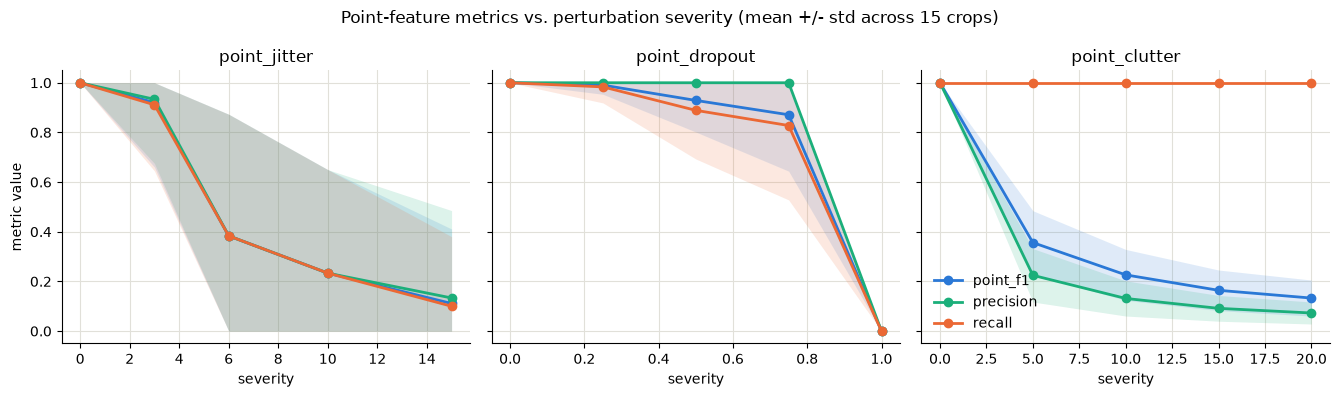

In [9]:
# Colorized small multiples for the point-feature sweep (same treatment as
# the road/building charts above).
if not point_results.empty:
    point_metric_cols = ["point_f1", "precision", "recall"]
    fig, axes = plt.subplots(1, len(POINT_PERTURBATIONS), figsize=(4.5 * len(POINT_PERTURBATIONS), 4),
                              sharey=True)
    for ax, pert_name in zip(axes, POINT_PERTURBATIONS):
        sub = point_results[point_results["perturbation"] == pert_name]
        stats = sub.groupby("severity")[point_metric_cols].agg(["mean", "std"])
        for metric in point_metric_cols:
            mean = stats[(metric, "mean")]
            std = stats[(metric, "std")]
            color = METRIC_COLORS[metric]
            ax.plot(mean.index, mean.values, marker="o", color=color, label=metric, linewidth=2)
            ax.fill_between(mean.index, (mean - std).clip(lower=0), (mean + std).clip(upper=1),
                             color=color, alpha=0.15, linewidth=0)
        ax.set_title(pert_name)
        ax.set_xlabel("severity")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, color="#e1e0d9", linewidth=0.8)
        ax.set_axisbelow(True)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)

    axes[0].set_ylabel("metric value")
    axes[-1].legend(loc="lower left", frameon=False)
    fig.suptitle("Point-feature metrics vs. perturbation severity (mean +/- std across 15 crops)")
    fig.tight_layout()
    plt.show()

## Observations

- **DTAF1's road-breakage blind spot (noted in CLAUDE.md) reproduces on real, branching road networks, and area-weighting does not fix it.** At `road_dropout` severity 0.75 (75% of road pixels deleted), `dtaf1` stays at 1.000 (mean across 24 tiles), while `cbhm` correctly collapses to ~0.57 (`cldice_mean` ~0.40). `dtaf1_weighted` also stays at 1.000 across every `road_dropout` severity -- area-weighting only changes how classes are *combined*, so it can't fix a per-pixel tolerance-matching blind spot that exists *within* the road class itself. This still needs the connectivity/topology term (APLS or connected-component ratio) CLAUDE.md already flags as the real fix.

- **CBHM and DTAF1 do sharply disagree on specific real tiles -- see `composite_vs_submetric_report.ipynb` for the detailed case study.** The largest disagreement is `Khartoum_img371` at a 12px road offset (`cbhm=0.000` vs `dtaf1=0.934`), driven by clDice's skeleton comparison collapsing to exactly 0 on a sparse road. `cbhm_soft`/`dtaf1_weighted` (the new area-weighted, non-collapsing companions) measurably soften this in aggregate -- e.g. `road_offset` severity 16: `cbhm` 0.669 -> `cbhm_soft` 0.712 -- but the composite report notebook found an important caveat: on `Khartoum_img371` itself, `cbhm_soft` only recovers to 0.285, because in that specific tile the road actually has *more* GT pixels than the building, so area-weighting leans toward the failing class rather than away from it. Area-weighting is a partial, tile-dependent mitigation, not a universal fix for skeleton brittleness.

- **point_f1 degrades noticeably faster on real, densely-packed Potsdam trees/cars than on the synthetic, evenly-scattered points in `tests/test_sensitivity.py`.** `point_jitter` drops to ~0.38 by a 6px jitter here vs. a cleaner, later drop-off synthetically -- real objects are often close enough together that the same jitter radius pushes a centroid past a neighboring instance or out of the fixed 5px tolerance. `point_dropout`/`point_clutter` behave exactly as designed (precision stays at 1.0 under dropout, recall stays at 1.0 under clutter), confirming the precision/recall decomposition is sound on real imagery even where the fixed tolerance isn't well tuned to real object density.